In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

# 设置图表样式
sns.set_style("whitegrid")
#导入必要库

In [2]:
train_path=r"D:\python专业版项目\Data science\competitions\titanic\data\raw\train.csv"
test_path=r"D:\python专业版项目\Data science\competitions\titanic\data\raw\test.csv"

train_df=pd.read_csv(train_path)
test_df=pd.read_csv(test_path)

print(f"训练数据形状：{train_df.shape}")
print(f"测试数据形状{test_df.shape}")

print("/n训练数据列名：")
print(train_df.columns.tolist())


训练数据形状：(891, 12)
测试数据形状(418, 11)
/n训练数据列名：
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [3]:
print("数据前5行：")
print(train_df.head(5))


数据前5行：
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN       

In [4]:
print("训练集信息：")
print(train_df.info())
print("测试集信息：")
print(test_df.info())


训练集信息：
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None
测试集信息：
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       41

In [5]:
train_df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# 查看缺失值
print("=== 缺失值分析 ===")
print("训练数据缺失情况:")
missing_train = train_df.isnull().sum()
missing_train_percent = (missing_train / len(train_df)) * 100
missing_table = pd.DataFrame({
    '缺失数量': missing_train,
    '缺失百分比': missing_train_percent
})
missing_table = missing_table[missing_table['缺失数量'] > 0]
missing_table.sort_values('缺失数量', ascending=False)


=== 缺失值分析 ===
训练数据缺失情况:


,缺失数量,缺失百分比
Cabin,687,77.104377
Age,177,19.865320
Embarked,2,0.224467


In [7]:
#-----------------------------------

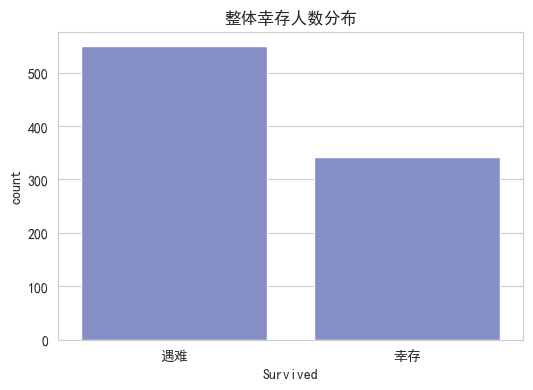

整体幸存率: 38.38%


In [11]:
# 1. 设置图形样式
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文显示
plt.rcParams['axes.unicode_minus'] = False


# 2. 总体幸存率
plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=train_df,color='#7B86D2')


plt.title('整体幸存人数分布')
plt.xticks([0,1], ['遇难', '幸存'])
plt.show()

survived_rate = train_df['Survived'].sum() / len(train_df)
print(f'整体幸存率: {survived_rate:.2%}')


C:\Users\一氧化二氧\AppData\Local\Temp\ipykernel_32340\691689567.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['男性', '女性'])


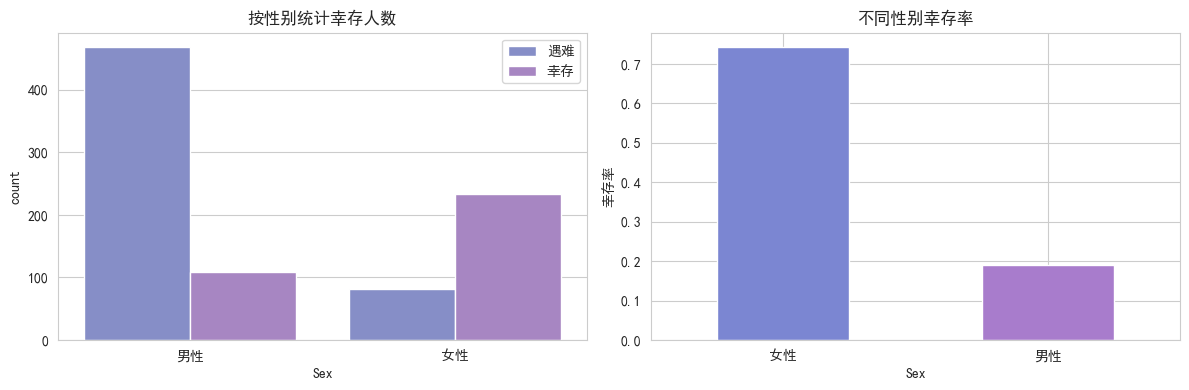

女性幸存率: 74.20%
男性幸存率: 18.89%


In [10]:
# 3. 性别与幸存关系
fig, axes = plt.subplots(1, 2, figsize=(12,4))

#创建两个子图

# 计数图
sns.countplot(x='Sex', hue='Survived', data=train_df, ax=axes[0],palette=['#7B86D2', '#A87CCC'])


axes[0].set_title('按性别统计幸存人数')
axes[0].set_xticklabels(['男性', '女性'])
axes[0].legend(['遇难', '幸存'])



sex_survived = train_df.groupby('Sex')['Survived'].mean()
sex_survived.plot(kind='bar', ax=axes[1], color=['#7B86D2', '#A87CCC'])
axes[1].set_title('不同性别幸存率')
axes[1].set_xticklabels(['女性', '男性'], rotation=0)
axes[1].set_ylabel('幸存率')

plt.tight_layout()
plt.show()

print(f'女性幸存率: {sex_survived["female"]:.2%}')
print(f'男性幸存率: {sex_survived["male"]:.2%}')



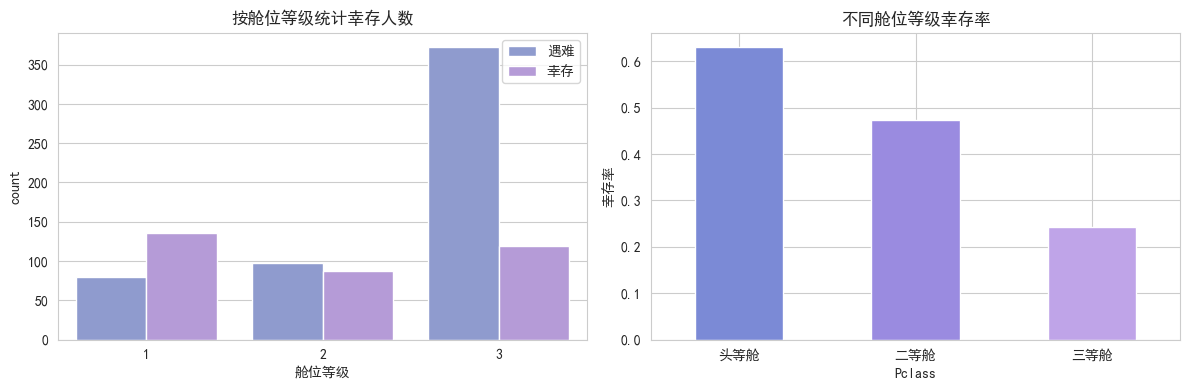

1等舱幸存率: 62.96%
2等舱幸存率: 47.28%
3等舱幸存率: 24.24%


In [12]:
# 4. 舱位等级与幸存关系
fig, axes = plt.subplots(1, 2, figsize=(12,4))


sns.countplot(x='Pclass', hue='Survived', data=train_df, ax=axes[0],
              palette=['#8594D8', '#B491E1'])

axes[0].set_title('按舱位等级统计幸存人数')
axes[0].set_xlabel('舱位等级')
axes[0].legend(['遇难', '幸存'])


pclass_survived = train_df.groupby('Pclass')['Survived'].mean()
pclass_survived.plot(kind='bar', ax=axes[1], color=['#7B8AD6', '#9A8BE0', '#BFA4E8'])

axes[1].set_title('不同舱位等级幸存率')
axes[1].set_xticklabels(['头等舱', '二等舱', '三等舱'], rotation=0)
axes[1].set_ylabel('幸存率')

plt.tight_layout()
plt.show()

for i, rate in enumerate(pclass_survived, 1):
    print(f'{i}等舱幸存率: {rate:.2%}')

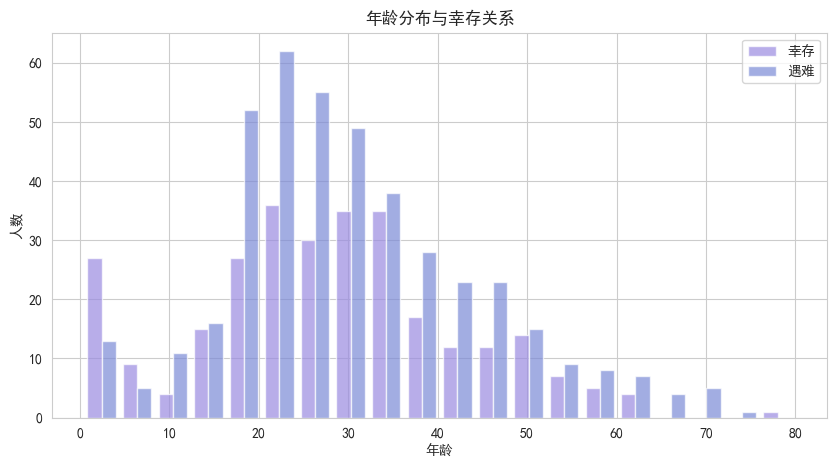

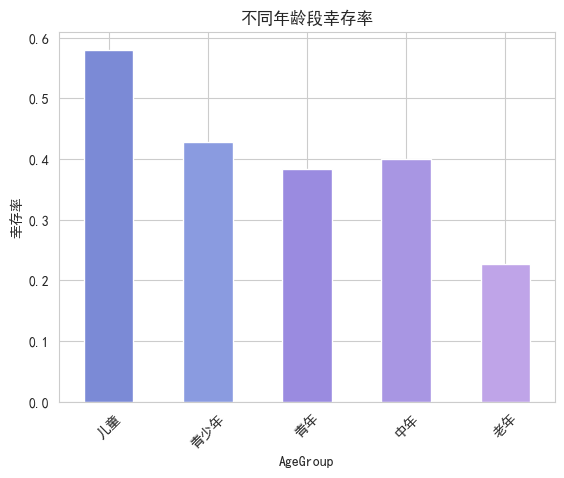

In [13]:
# 5. 年龄分布与幸存关系
plt.figure(figsize=(10,5))
plt.hist([train_df[train_df['Survived']==1]['Age'].dropna(),
          train_df[train_df['Survived']==0]['Age'].dropna()],
         bins=20, label=['幸存', '遇难'], alpha=0.7,color=['#9A8BE0', '#7B8AD6'])


plt.xlabel('年龄')
plt.ylabel('人数')
plt.title('年龄分布与幸存关系')
plt.legend()
plt.show()

# 年龄分组统计
bins = [0, 12, 18, 35, 60, 100]
labels = ['儿童', '青少年', '青年', '中年', '老年']
train_df['AgeGroup'] = pd.cut(train_df['Age'], bins=bins, labels=labels)

age_survived = train_df.groupby('AgeGroup')['Survived'].mean()
age_survived.plot(kind='bar', color=['#7B8AD6', '#8A9BE0', '#9A8BE0', '#A896E3', '#BFA4E8'])


"""
countplot = 统计加画图
hist = 将连续型数据划分成不同的区间并且画图
plot = 运用已知数据画出图形
"""

plt.title('不同年龄段幸存率')
plt.ylabel('幸存率')
plt.xticks(rotation=45)  #将文本标签旋转多少度
plt.show()


C:\Users\一氧化二氧\AppData\Local\Temp\ipykernel_32340\3735793701.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['C', 'Q', 'S'])


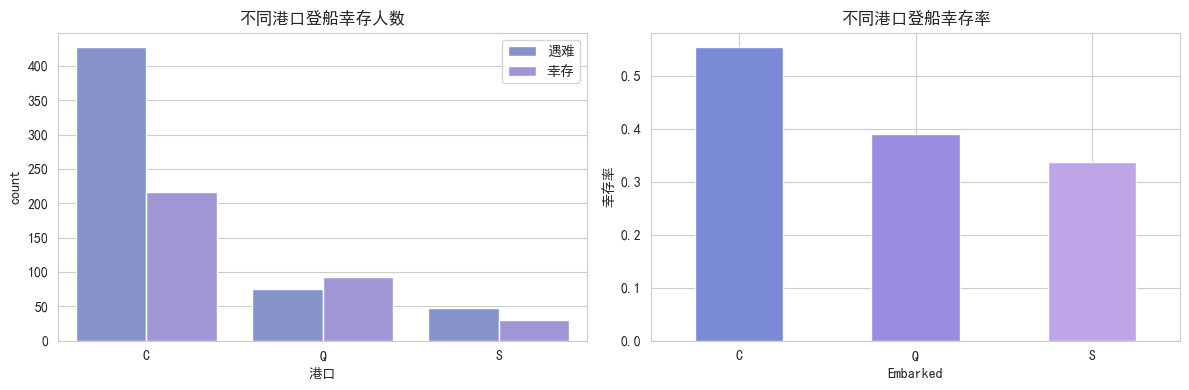

In [16]:
# 6. 登船港口与幸存关系
fig, axes = plt.subplots(1,2, figsize=(12,4))

# 计数图
sns.countplot(x='Embarked', hue='Survived', data=train_df, ax=axes[0],
              palette=['#7B8AD6', '#9A8BE0'])

axes[0].set_title('不同港口登船幸存人数')
axes[0].set_xlabel('港口')
axes[0].set_xticklabels(['C', 'Q', 'S'])
axes[0].legend(['遇难', '幸存'])

# 比例图
embarked_survived = train_df.groupby('Embarked')['Survived'].mean()
embarked_survived.plot(kind='bar', ax=axes[1], color=['#7B8AD6', '#9A8BE0', '#BFA4E8'])

axes[1].set_title('不同港口登船幸存率')
axes[1].set_xticklabels(['C', 'Q', 'S'], rotation=0)
axes[1].set_ylabel('幸存率')

plt.tight_layout()
plt.show()

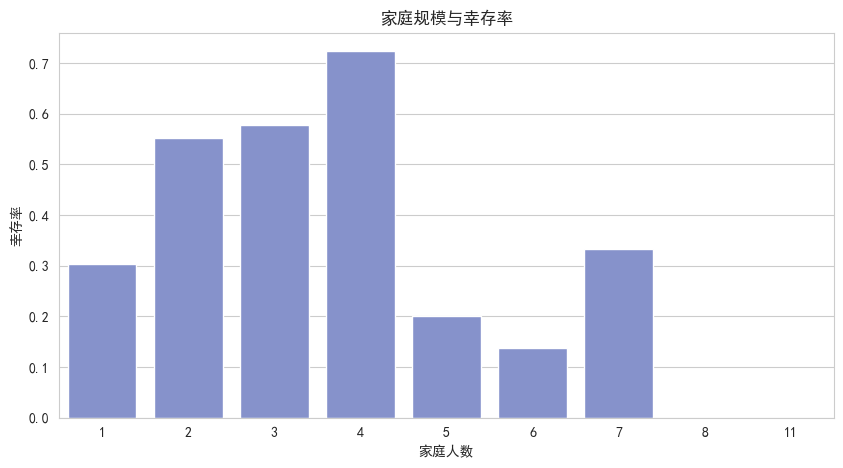

单独一人幸存率: 30.35%
有家人幸存率: 50.56%


In [17]:

train_df['FamilySize'] = train_df['SibSp'] + train_df['Parch'] + 1
plt.figure(figsize=(10,5))
sns.barplot(x='FamilySize', y='Survived', data=train_df, errorbar=None,color='#7B8AD6')


plt.title('家庭规模与幸存率')
plt.xlabel('家庭人数')
plt.ylabel('幸存率')
plt.show()

# 单独一人 vs 有家人
train_df['IsAlone'] = (train_df['FamilySize'] == 1).astype(int)
alone_survived = train_df.groupby('IsAlone')['Survived'].mean()
print(f'单独一人幸存率: {alone_survived[1]:.2%}')
print(f'有家人幸存率: {alone_survived[0]:.2%}')


In [21]:
alone_survived

IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

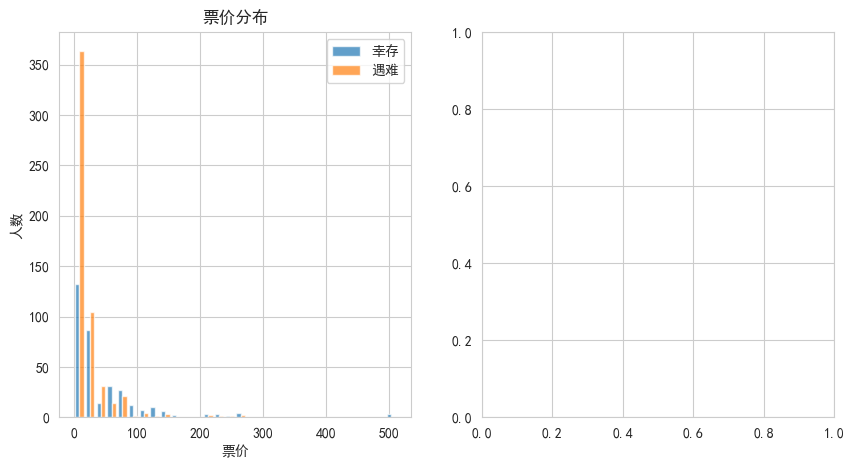

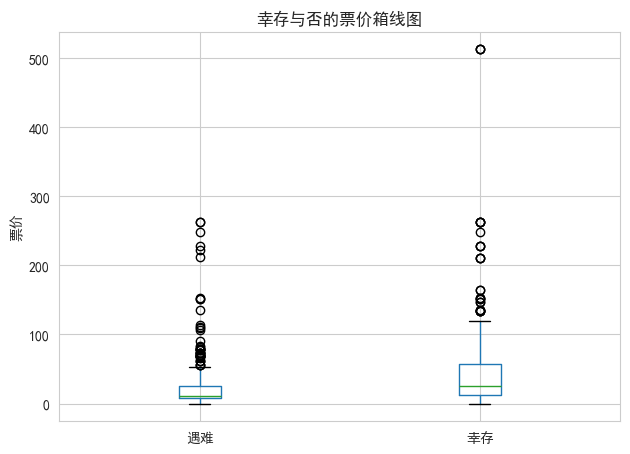

In [23]:
# 8. 票价分布与幸存关系
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist([train_df[train_df['Survived']==1]['Fare'].dropna(),
          train_df[train_df['Survived']==0]['Fare'].dropna()],
         bins=30, label=['幸存', '遇难'], alpha=0.7)
plt.xlabel('票价')
plt.ylabel('人数')
plt.title('票价分布')
plt.legend()

plt.subplot(1,2,2)
train_df[['Fare', 'Survived']].boxplot(by='Survived')



plt.title('幸存与否的票价箱线图')
plt.suptitle('')
plt.xticks([1,2], ['遇难', '幸存'])

plt.xlabel('')
plt.ylabel('票价')
plt.tight_layout()
plt.show()
